1. Charger les 3 versions

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv("../data/raw/donnees_retail.csv")
df_eda = pd.read_csv("../data/processed/step1_exploration.csv") 
df_clean = pd.read_csv("../data/processed/step2_cleaning.csv")

2. Comparer valeurs manquantes

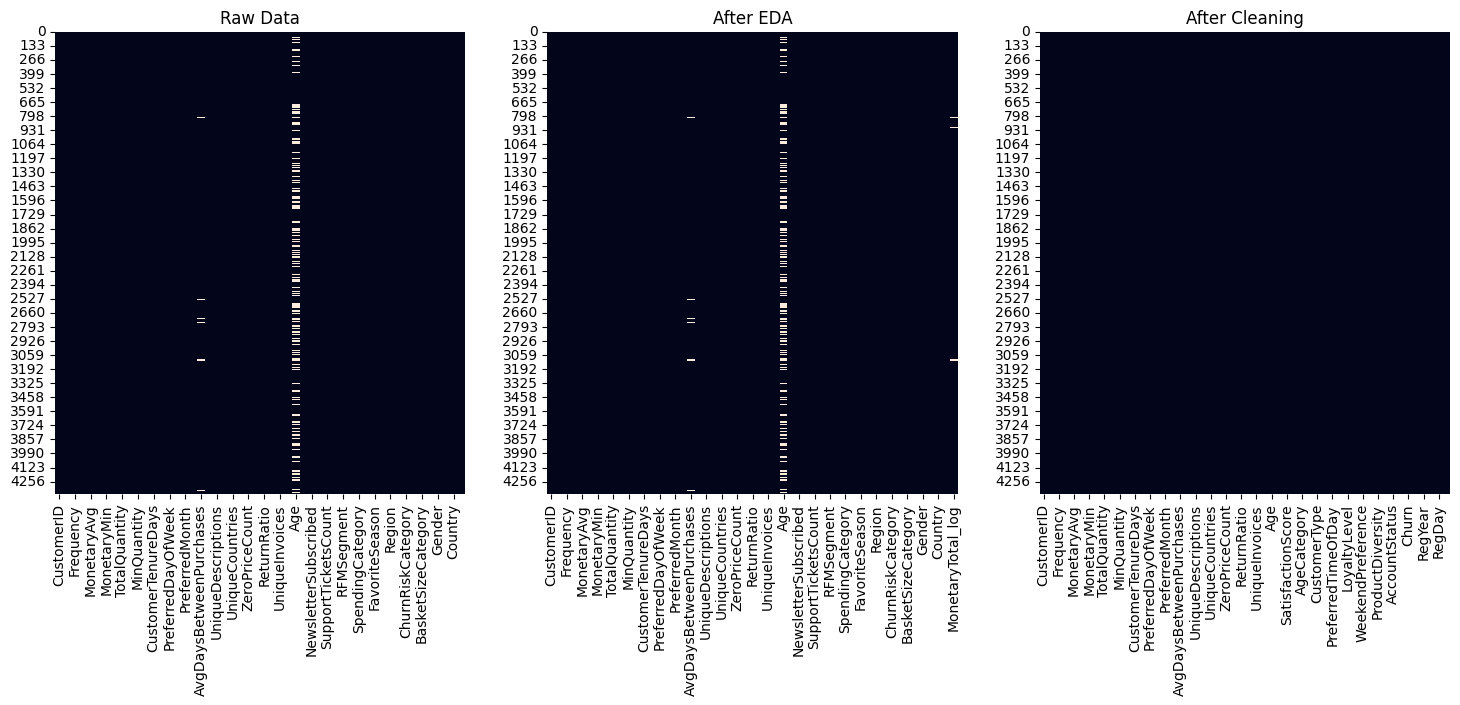

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.heatmap(df_raw.isnull(), cbar=False, ax=axes[0])
axes[0].set_title("Raw Data")

sns.heatmap(df_eda.isnull(), cbar=False, ax=axes[1])
axes[1].set_title("After EDA")

sns.heatmap(df_clean.isnull(), cbar=False, ax=axes[2])
axes[2].set_title("After Cleaning")

plt.show()


3. Comparer distribution de features clés

C:\Users\chaie\AppData\Local\Temp\ipykernel_16192\1292044940.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_raw['Age'], label='Raw', shade=True)
C:\Users\chaie\AppData\Local\Temp\ipykernel_16192\1292044940.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_eda['Age'], label='After EDA', shade=True)
C:\Users\chaie\AppData\Local\Temp\ipykernel_16192\1292044940.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_clean['Age'], label='After Cleaning', shade=True)


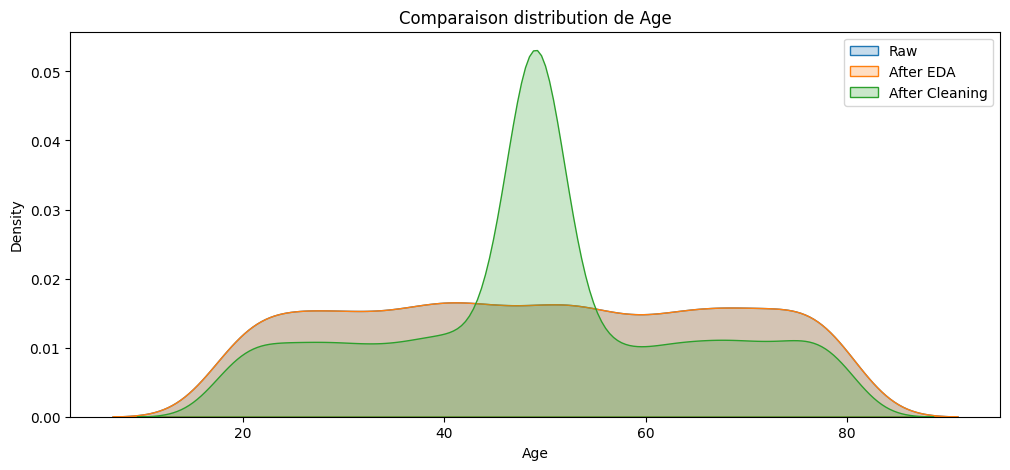

In [8]:
plt.figure(figsize=(12,5))
sns.kdeplot(df_raw['Age'], label='Raw', shade=True)
sns.kdeplot(df_eda['Age'], label='After EDA', shade=True)
sns.kdeplot(df_clean['Age'], label='After Cleaning', shade=True)
plt.title("Comparaison distribution de Age")
plt.legend()
plt.show()


In [9]:
nan_raw = df_raw.isnull().sum()
nan_clean = df_clean.isnull().sum()

nan_comparison = pd.DataFrame({
    "NaN_Raw": nan_raw,
    "NaN_Clean": nan_clean
})

# garder seulement les colonnes concernées
nan_comparison = nan_comparison[(nan_comparison["NaN_Raw"] > 0) | (nan_comparison["NaN_Clean"] > 0)]

nan_comparison.sort_values(by="NaN_Raw", ascending=False)


,NaN_Raw,NaN_Clean
Age,1311.0,0.0
AvgDaysBetweenPurchases,79.0,0.0


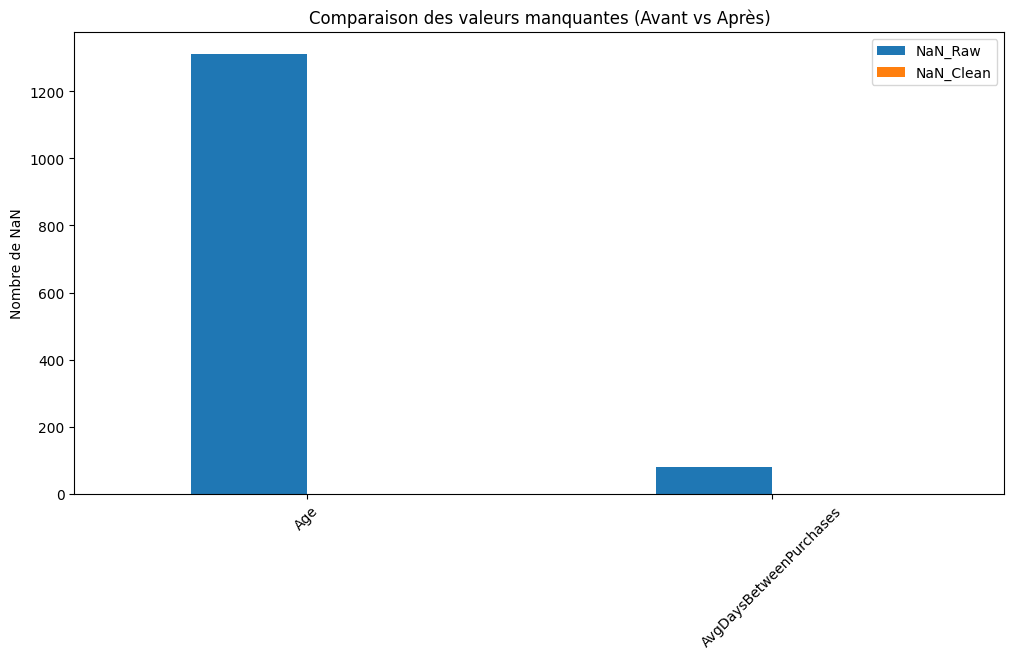

In [10]:
nan_comparison.plot(kind='bar', figsize=(12,6))
plt.title("Comparaison des valeurs manquantes (Avant vs Après)")
plt.ylabel("Nombre de NaN")
plt.xticks(rotation=45)
plt.show()

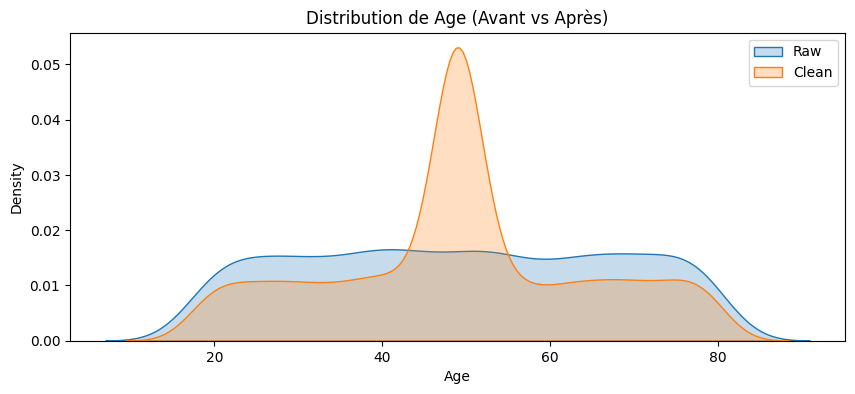

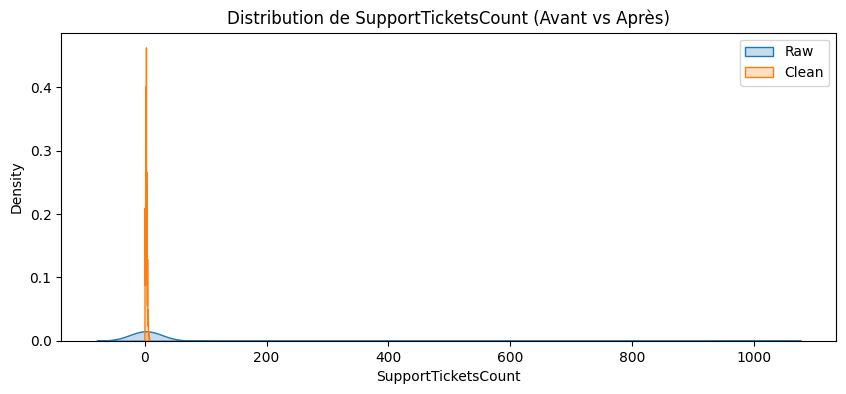

In [14]:
features = ['Age', 'SupportTicketsCount']

for col in features:
    plt.figure(figsize=(10,4))
    
    sns.kdeplot(df_raw[col], label="Raw", fill=True)
    sns.kdeplot(df_clean[col], label="Clean", fill=True)
    
    plt.title(f"Distribution de {col} (Avant vs Après)")
    plt.legend()
    plt.show()
